### Провести касательную к графику функции у = х^2 + 2 в точке с абсциссой х0 = 2.

In [3]:
import numpy as np
from sympy.abc import x
import matplotlib.pyplot as plt

In [1]:
!pip install sympy


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


y(x): x**2 + 2
x0  : 2
Касательная как выражение: 4*x - 2
Касательная через Line   : -4*x + y + 2


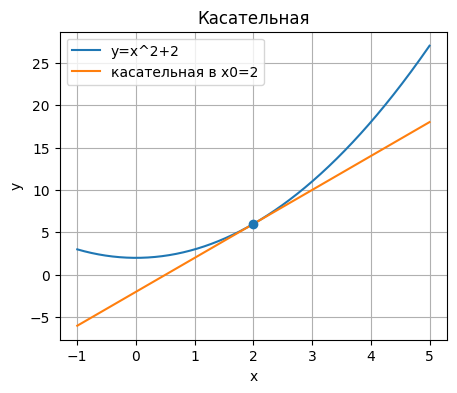

In [6]:
# Строит уравнение касательной к графику функции у(х) в точке с абсциссой х0 (х0;у0) - точка касания 
# Производная функции у при х=х0 
from sympy import symbols, diff, Line, Point, simplify

y = x**2 + 2
x0 = 2
y0=y.subs(x,x0)
#y0 = 4
    
k = diff(y,x).subs(x,x0)
yt = simplify(k*(x-x0)+y0)
L = Line(Point(x0,y0), slope=k)

print("y(x):", y)
print("x0  :", x0)
print("Касательная как выражение:", yt)
print("Касательная через Line   :", L.equation())

f  = lambda t: t**2 + 2
ft = lambda t: 4*t - 2

t = np.linspace(-1, 5, 400)
plt.figure(figsize=(5,4))
plt.plot(t, f(t), label="y=x^2+2")
plt.plot(t, ft(t), label="касательная в x0=2")
plt.scatter([x0], [f(x0)], zorder=3)
plt.legend(); plt.grid(True); plt.xlabel("x"); plt.ylabel("y"); plt.title("Касательная")
plt.show()

### 1. Построить график функции y=x^2 + 2 и касательной в точке x0=2

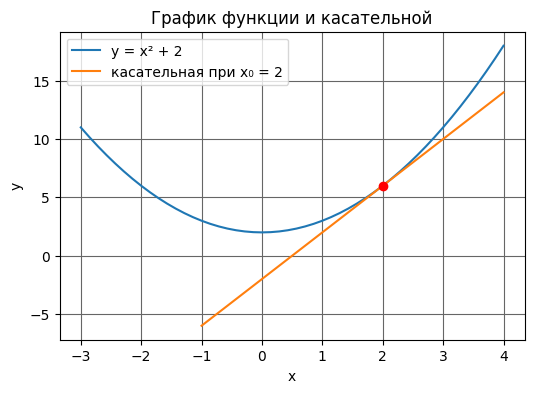

In [7]:
#в этом варианте код просто подготовлен для численного построения с помощью numpy и matplotlib.
x = np.linspace(-3,4,50)
y  = x**2 + 2  

x1 = np.linspace(-1,4,50)
y1 = 4*x1 - 2

# Сетка 
plt.figure(figsize=(6,4))
plt.plot(x, y,  label='y = x² + 2')
plt.plot(x1, y1, label='касательная при x₀ = 2')
plt.scatter([2], [6], color='red', zorder=3)

plt.title('График функции и касательной')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='-', color='0.4')
plt.legend()
plt.show()

### 2. Исследовать на экстремум функцию у = е^х - е^(2х)

In [15]:
from sympy import symbols, exp, diff, solveset, S, limit, oo, ln, simplify

#### График функции на отрезке [-12; 5]



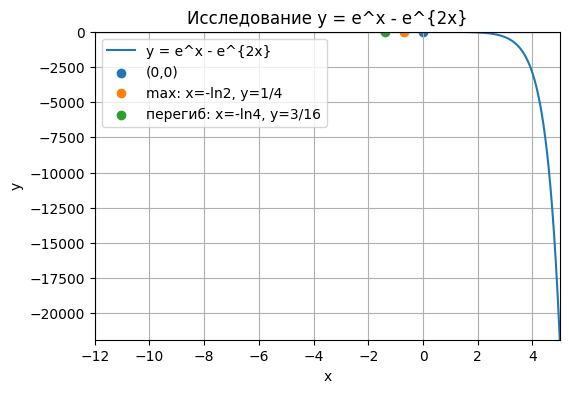

In [16]:
import numpy as np
import matplotlib.pyplot as plt

f  = lambda t: np.exp(t) - np.exp(2*t)

xs = np.linspace(-12, 5, 800)
ys = f(xs)

plt.figure(figsize=(6,4))
plt.plot(xs, ys, label="y = e^x - e^{2x}")
plt.axhline(0, lw=1, alpha=0.6)                 # ось OX и асимптота слева
plt.scatter([0],    [0],    label="(0,0)")
plt.scatter([-np.log(2)], [0.25], label="max: x=-ln2, y=1/4")
plt.scatter([-np.log(4)], [3/16], label="перегиб: x=-ln4, y=3/16")

plt.xlim(-12, 5)
plt.ylim(min(-5, ys.min()), 1)
plt.grid(True)
plt.xlabel("x"); plt.ylabel("y"); plt.title("Исследование y = e^x - e^{2x}")
plt.legend()
plt.show()


In [19]:
from sympy import symbols, exp, diff, solveset, S, limit, oo, ln, simplify
x = symbols('x', real=True)
y = exp(x) - exp(2*x)
domain = S.Reals

Область определения: Reals


#### 1. Область определения:



In [20]:
print("Область определения:", domain)

Область определения: Reals


#### 2. Пересечение с осями  X и Y.



In [21]:
y0 = y.subs(x, 0)                      
x0 = solveset(y, x, domain=domain)     
print("Пересечение с OY:", (0, y0))
print("Пересечение с OX:", list(x0))

Пересечение с OY: (0, 0)
Пересечение с OX: [0]


#### 3. Асимптоты.



In [22]:
limLeft  = limit(y, x, -oo)
limRight = limit(y, x,  oo)
k = limit(y/x, x, oo)
print("lim x→-∞ y =", limLeft, "→ горизонтальная y=0 слева")
print("lim x→+∞ y =", limRight, "; k=", k, "→ наклонной нет")
print("k =", k)

lim x→-∞ y = 0 → горизонтальная y=0 слева
lim x→+∞ y = -oo ; k= -oo → наклонной нет
k = -oo


#### 4. Экстремумы и интервалы монотонности





In [23]:
y1   = diff(y, x)
crit = solveset(y1, x, domain=domain)  # {-ln(2)}
xMax = -ln(2)
yMax = y.subs(x, xMax)
print("y' =", simplify(y1))
print("Критическая точка:", list(crit))
print("Максимум в x=-ln2, y=", yMax)
print("Монотонность: ↑ на (-∞, -ln2), ↓ на (-ln2, +∞)")

y' = (1 - 2*exp(x))*exp(x)
Критическая точка: [-log(2)]
Максимум в x=-ln2, y= 1/4
Монотонность: ↑ на (-∞, -ln2), ↓ на (-ln2, +∞)


#### 5. Интервалы выпуклости и точки перегиба графика функции.




In [24]:
y2   = diff(y1, x)
infl = solveset(y2, x, domain=domain)  # {-ln(4)}
xInf = -ln(4)
yInf = y.subs(x, xInf)
print("y'' =", simplify(y2))
print("Точка перегиба:", list(infl), "значение y=", yInf)
print("Выпуклость: вверх (-∞, -ln4), вниз (-ln4, +∞)")

y'' = (1 - 4*exp(x))*exp(x)
Точка перегиба: [-log(4)] значение y= 3/16
Выпуклость: вверх (-∞, -ln4), вниз (-ln4, +∞)


### 3. Провести полное исследование функции
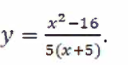

In [25]:
from sympy import factor, apart, Eq

x = symbols('x', real=True)
y = (x**2 - 16) / (5*(x + 5))
domain = S.Reals


Область определения

In [26]:
print("Область определения:", f"ℝ \\ {{-5}}")

Область определения: ℝ \ {-5}


Пересечение с осями X и Y

In [27]:
y0 = y.subs(x, 0)                        
x0 = solveset(Eq(y, 0), x, domain=domain)
print("Пересечение с OY:", (0, y0))
print("Пересечения с OX:", list(x0))

Пересечение с OY: (0, -16/25)
Пересечения с OX: [-4, 4]


Асимптоты

In [28]:
k = limit(y/x, x, oo)
b = limit(y - k*x, x, oo)
print("Вертикальная асимптота: x = -5")
print("Наклонная асимптота: y =", k, "* x +", b)
print("Разложение:", apart(y))

Вертикальная асимптота: x = -5
Наклонная асимптота: y = 1/5 * x + -1
Разложение: x/5 - 1 + 9/(5*(x + 5))


Экстремумы и интервалы монотонности

In [29]:
y1   = diff(y, x)
crit = solveset(Eq(y1, 0), x, domain=domain)
x1, x2 = sorted(list(crit))
y_at_x1 = y.subs(x, x1)
y_at_x2 = y.subs(x, x2)
print("y' =", simplify(y1))
print("Критические точки:", list(crit))
print("Значения: y(-8) =", y_at_x1, ", y(-2) =", y_at_x2)
print("Монотонность: ↑ на (-∞,-8)∪(-2,∞); ↓ на (-8,-5)∪(-5,-2)")


y' = (-x**2 + 2*x*(x + 5) + 16)/(5*(x + 5)**2)
Критические точки: [-8, -2]
Значения: y(-8) = -16/5 , y(-2) = -4/5
Монотонность: ↑ на (-∞,-8)∪(-2,∞); ↓ на (-8,-5)∪(-5,-2)


Интервалы выпуклости и точки перегиба графика функции

In [30]:
y2   = diff(y1, x)
print("y'' =", simplify(y2))
print("Выпуклость: вниз на (-∞,-5), вверх на (-5,∞)")
print("Точек перегиба в области определения нет (смена выпуклости в x=-5, где функция не определена).")

y'' = 18/(5*(x**3 + 15*x**2 + 75*x + 125))
Выпуклость: вниз на (-∞,-5), вверх на (-5,∞)
Точек перегиба в области определения нет (смена выпуклости в x=-5, где функция не определена).


График

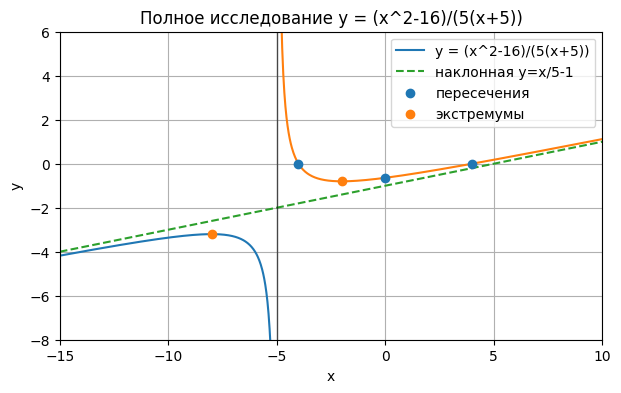

In [31]:
f  = lambda t: (t**2 - 16) / (5*(t + 5))
fa = lambda t: t/5 - 1 

xl = np.linspace(-15, -5.2, 600)
xr = np.linspace(-4.8, 10,   600)

plt.figure(figsize=(7,4))
plt.plot(xl, f(xl), label="y = (x^2-16)/(5(x+5))")
plt.plot(xr, f(xr))
plt.plot(np.r_[xl,xr], fa(np.r_[xl,xr]), linestyle="--", label="наклонная y=x/5-1")


plt.axvline(-5, color='k', lw=1, alpha=0.6)
plt.scatter([0, -4, 4], [f(0), 0, 0], zorder=3, label="пересечения")
plt.scatter([-8, -2], [f(-8), f(-2)], zorder=3, label="экстремумы")

plt.xlim(-15, 10); plt.ylim(-8, 6)
plt.grid(True); plt.xlabel("x"); plt.ylabel("y")
plt.title("Полное исследование y = (x^2-16)/(5(x+5))")
plt.legend(); plt.show()

### 4. Провести полное исследование функции
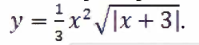

Область определения

In [49]:
from sympy import symbols, Abs, sqrt, diff, solveset, Eq, S, limit, oo, simplify, solve, Eq
from sympy import FiniteSet
x = symbols('x', real=True)
y = (x**2/3) * sqrt(Abs(x+3))
domain = S.Reals
print("Область определения:", domain)

Область определения: Reals


Пересечение с осями X и Y

In [43]:
y_OY = y.subs(x, 0)
x_OX = solveset(Eq(y, 0), x, domain=domain)
print("Пересечение с OY:", (0, y_OY))
print("Пересечения с OX:", list(x_OX))

Пересечение с OY: (0, 0)
Пересечения с OX: [-3, 0]


Асимптоты

In [44]:
lim_left  = limit(y, x, -oo)
lim_right = limit(y, x,  oo)
print("Горизонтальных/наклонных асимптот нет; вертикальных нет (область = ℝ).")

Горизонтальных/наклонных асимптот нет; вертикальных нет (область = ℝ).


Экстремумы и интервалы монотонности

In [45]:
# Учитываем |x+3| → производная кусочная; sympy даёт Piecewise
y1   = diff(y, x)
crit = solveset(Eq(y1, 0), x, domain=domain)
# Точка недифференцируемости x=-3 тоже критическая
crit_all = sorted(list(crit.union(FiniteSet(-3))))
y_vals = [(xi, simplify(y.subs(x, xi))) for xi in crit_all]
print("y' =", y1)
print("Критические точки (вкл. недифф.):", crit_all)
print("Значения в них:", y_vals)
print("Монотонность: ↓ на (-∞,-3), ↑ на (-3,-12/5), ↓ на (-12/5,0), ↑ на (0,∞)")
print("Типы: min в x=-3 и x=0; max в x=-12/5")

y' = x**2*sign(x + 3)/(6*sqrt(Abs(x + 3))) + 2*x*sqrt(Abs(x + 3))/3
Критические точки (вкл. недифф.): [-3, -12/5, 0]
Значения в них: [(-3, 0), (-12/5, 48*sqrt(15)/125), (0, 0)]
Монотонность: ↓ на (-∞,-3), ↑ на (-3,-12/5), ↓ на (-12/5,0), ↑ на (0,∞)
Типы: min в x=-3 и x=0; max в x=-12/5


Интервалы выпуклости и точки перегиба графика функции

In [50]:
# Левая ветка: x < -3  →  sqrt(|x+3|) = sqrt(-x-3)
yL  = (x**2/3) * sqrt(-x-3)
y1L = diff(yL, x)
y2L = simplify(diff(y1L, x))

# Правая ветка: x ≥ -3 →  sqrt(|x+3|) = sqrt(x+3)
yR  = (x**2/3) * sqrt(x+3)
y1R = diff(yR, x)
y2R = simplify(diff(y1R, x))

print("y''_L =", y2L)
print("y''_R =", y2R)

# Решаем по веткам
sol_L = [s for s in solve(Eq(5*x**2 + 24*x + 24, 0)) if s < -3]
sol_R = [s for s in solve(Eq(5*x**2 + 24*x + 24, 0)) if s >= -3]
print("Перегиб слева (x<-3):", sol_L)
print("Перегиб справа (x>=-3):", sol_R)

y''_L = sqrt(-x - 3)*(5*x**2 + 24*x + 24)/(4*(x**2 + 6*x + 9))
y''_R = (5*x**2 + 24*x + 24)/(4*(x + 3)**(3/2))
Перегиб слева (x<-3): [-12/5 - 2*sqrt(6)/5]
Перегиб справа (x>=-3): [-12/5 + 2*sqrt(6)/5]


График

In [53]:
%config InlineBackend.figure_formats = {'png'}
f = lambda t: (t**2/3.0) * np.sqrt(np.abs(t+3))

xs = np.linspace(-10, 8, 800)
ys = f(xs)

plt.figure(figsize=(7,4))
plt.plot(xs, ys, label=r"$y=\frac13 x^2\sqrt{|x+3|}$")

plt.scatter([-3, 0], [0, 0], zorder=3, label="минимумы x=-3, 0")
xmax = -12/5
plt.scatter([xmax], [f(xmax)], zorder=3, label="максимум x=-12/5")

plt.grid(True); plt.xlabel("x"); plt.ylabel("y")
plt.title(r"Полное исследование $y=\frac13 x^2\sqrt{|x+3|}$")
plt.legend(); plt.show()


NameError: name 'png' is not defined